In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [2]:
master = pd.read_csv(
    "../data/processed/master_features.csv"
)

master.head()

,State,District,Year,Temperature,Min_Temperature,Max_Temperature,Rainfall,wspd,pres,Forest_Loss,...,State_ID,District_ID,Temp_Range,Rainfall_per_Elevation,Vegetation_Forest_Index,Temperature_Scaled,Rainfall_Scaled,NDVI_Scaled,Forest_Loss_Scaled,Elevation_Scaled
0,Karnataka,Shivamogga,2021.0,24.506868,13.2,37.2,1779.7,8.926923,1010.807967,0.019144,...,1,4,24.0,2.621533,0.424327,-1.615758,-1.222850,0.489407,1.282355,1.126707
1,Karnataka,Shivamogga,2022.0,24.796006,12.8,37.0,1452.4,9.242424,1010.384298,0.019144,...,1,4,24.2,2.139414,0.431454,-1.455626,-1.597997,0.534931,1.282355,1.126707
2,Karnataka,Shivamogga,2023.0,25.862466,13.0,39.3,751.4,11.691781,1011.566575,0.019144,...,1,4,26.3,1.106827,0.437099,-0.864994,-2.401474,0.570987,1.282355,1.126707
3,Karnataka,Shivamogga,2024.0,25.993820,13.9,41.0,1359.0,10.768820,1010.710112,0.019144,...,1,4,27.1,2.001834,0.412997,-0.792246,-1.705051,0.417031,1.282355,1.126707
4,Karnataka,Uttara Kannada,2015.0,27.601681,20.4,35.5,3006.5,9.943332,1009.976558,0.008988,...,1,7,15.1,6.975929,0.542703,0.098227,0.183291,1.210040,-0.348361,0.212802


In [3]:
print("Districts:")
print(sorted(master["District"].unique()))

print("\nYears:")
print(sorted(master["Year"].unique()))

Districts:
['Chikkamagaluru', 'Kannur', 'Kodagu', 'North Goa', 'Shivamogga', 'Sindhudurg', 'South Goa', 'Uttara Kannada', 'Wayanad']

Years:
[np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0)]


In [4]:
dashboard_summary = (
    master
    .groupby(["State", "District"])
    .agg(
        Mean_Temperature=("Temperature", "mean"),
        Mean_Rainfall=("Rainfall", "mean"),
        Mean_NDVI=("NDVI", "mean"),
        Forest_Loss=("Forest_Loss", "mean"),
        Elevation=("Elevation", "mean")
    )
    .reset_index()
)

dashboard_summary.head()

,State,District,Mean_Temperature,Mean_Rainfall,Mean_NDVI,Forest_Loss,Elevation
0,Goa,North Goa,28.151297,2957.830,0.152614,0.006371,71.222575
1,Goa,South Goa,28.165584,3100.050,0.270724,0.004198,211.357774
2,Karnataka,Chikkamagaluru,27.169937,1872.125,0.469128,0.018034,890.594716
3,Karnataka,Kodagu,25.682345,2617.610,0.552279,0.021077,682.786387
4,Karnataka,Shivamogga,25.289790,1335.625,0.434793,0.019144,677.877599


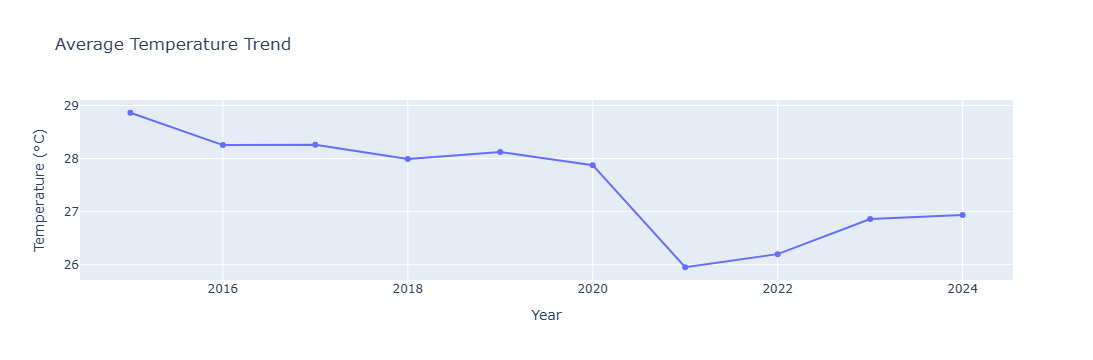

In [5]:
temperature_trend = (
    master
    .groupby("Year")["Temperature"]
    .mean()
    .reset_index()
)

fig = px.line(
    temperature_trend,
    x="Year",
    y="Temperature",
    markers=True,
    title="Average Temperature Trend"
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Temperature (°C)"
)

fig.show()

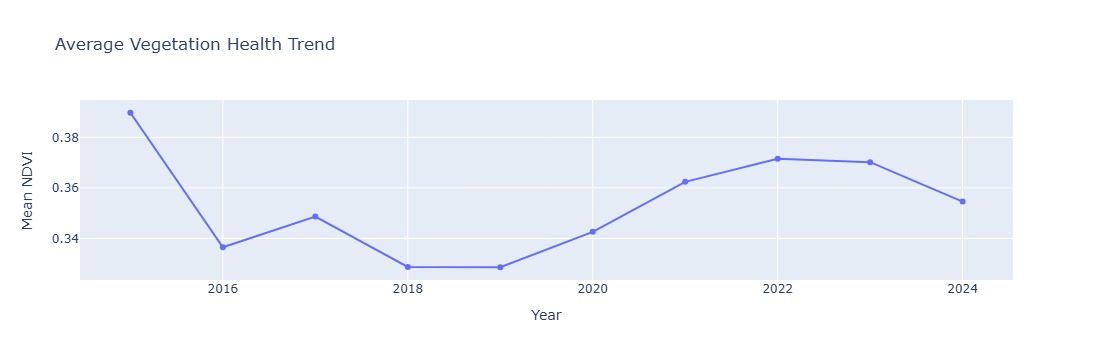

In [6]:
ndvi_trend = (
    master
    .groupby("Year")["NDVI"]
    .mean()
    .reset_index()
)

fig = px.line(
    ndvi_trend,
    x="Year",
    y="NDVI",
    markers=True,
    title="Average Vegetation Health Trend"
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Mean NDVI"
)

fig.show()

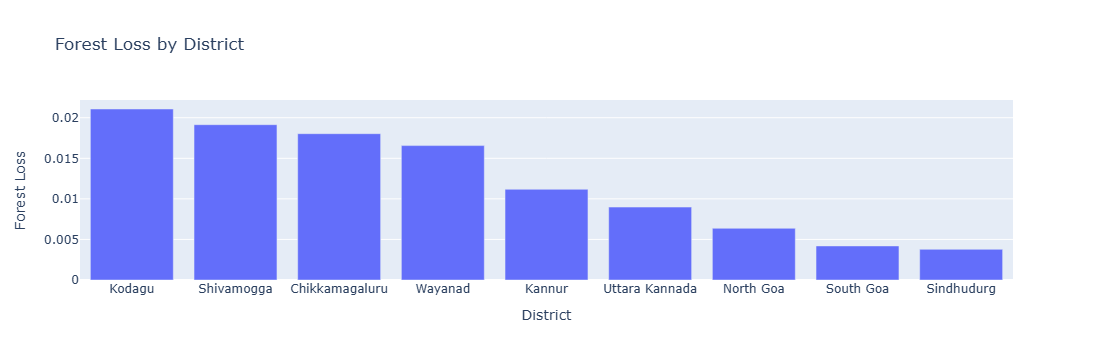

In [7]:
forest_summary = (
    master
    .groupby("District")["Forest_Loss"]
    .mean()
    .reset_index()
    .sort_values("Forest_Loss", ascending=False)
)

fig = px.bar(
    forest_summary,
    x="District",
    y="Forest_Loss",
    title="Forest Loss by District"
)

fig.update_layout(
    xaxis_title="District",
    yaxis_title="Forest Loss"
)

fig.show()

In [8]:
master["Environmental_Risk_Score"] = (
    0.30 * master["Temperature"].rank(pct=True)
    + 0.25 * master["Rainfall"].rank(pct=True)
    + 0.20 * (1 - master["NDVI"].rank(pct=True))
    + 0.25 * master["Forest_Loss"].rank(pct=True)
)

master["Environmental_Risk_Score"] = (
    master["Environmental_Risk_Score"] * 100
)

In [9]:
def classify_risk(score):

    if score < 33:
        return "Low Risk"

    elif score < 66:
        return "Moderate Risk"

    else:
        return "High Risk"


master["Environmental_Risk_Level"] = (
    master["Environmental_Risk_Score"]
    .apply(classify_risk)
)

In [10]:
master[
    [
        "District",
        "Year",
        "Environmental_Risk_Score",
        "Environmental_Risk_Level"
    ]
].head(20)

,District,Year,Environmental_Risk_Score,Environmental_Risk_Level
0,Shivamogga,2021.0,34.391026,Moderate Risk
1,Shivamogga,2022.0,34.583333,Moderate Risk
2,Shivamogga,2023.0,35.288462,Moderate Risk
3,Shivamogga,2024.0,37.083333,Moderate Risk
4,Uttara Kannada,2015.0,35.288462,Moderate Risk
5,Uttara Kannada,2016.0,47.532051,Moderate Risk
6,Uttara Kannada,2017.0,50.160256,Moderate Risk
7,Uttara Kannada,2018.0,40.801282,Moderate Risk
8,Uttara Kannada,2019.0,54.775641,Moderate Risk
9,Uttara Kannada,2020.0,48.685897,Moderate Risk


In [11]:
master.to_csv(
    "../data/processed/dashboard_environment_data.csv",
    index=False
)

print("Dashboard dataset saved successfully.")

Dashboard dataset saved successfully.


In [12]:
import json
import joblib
import pandas as pd

dashboard = pd.read_csv(
    "../data/processed/dashboard_environment_data.csv"
)

model = joblib.load(
    "../outputs/models/kfd_outbreak_model_v3.pkl"
)

with open(
    "../outputs/models/kfd_outbreak_model_v3_metadata.json",
    "r",
    encoding="utf-8"
) as f:
    metadata = json.load(f)

print("=" * 72)
print("DASHBOARD V3 AUDIT")
print("=" * 72)

print("Dashboard rows:", len(dashboard))
print("Districts:", dashboard["District"].nunique())

print(
    "Unique NDVI values:",
    dashboard["NDVI"].nunique()
)

print(
    "NDVI std:",
    round(
        dashboard["NDVI"].std(),
        6
    )
)

print("\nModel:")
print(metadata["model_name"])

print("\nFeatures:")
print(metadata["features"])

print("\nValidation:")
print(metadata["validation"])

print("\nMetrics:")
display(
    pd.DataFrame(
        [metadata["metrics"]]
    ).round(3)
)

DASHBOARD V3 AUDIT
Dashboard rows: 78
Districts: 9
Unique NDVI values: 78
NDVI std: 0.160637

Model:
Dynamic Decision Tree

Features:
['Temperature', 'Rainfall', 'NDVI', 'Temp_Range']

Validation:
Leave-One-District-Out

Metrics:


,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.652,0.652,0.652,0.652,0.652,0.519,0.544
